# 🔗 Correlation Analysis

## 🎯 Learning Objectives

After completing this notebook, you will be able to:

- Understand correlation and its importance.
- Differentiate between positive and negative correlation.
- Calculate correlation using Pandas.
- Interpret a correlation matrix.
- Visualize correlations.
- Understand multicollinearity.
- Use correlation for feature selection.

## 📖 Introduction

Correlation measures the strength and direction of the relationship between two numerical variables.

It helps identify whether one variable increases, decreases, or remains unchanged as another variable changes.

Correlation is widely used in Exploratory Data Analysis (EDA), Feature Selection, and Machine Learning.

## ❓ What is Correlation?

Correlation tells us how strongly two variables are related.

Example:

- Age and Fare
- Fare and Passenger Class
- Age and Siblings

Correlation does **not** imply causation. Two variables may be correlated without one causing the other.

## 📚 Types of Correlation

### Positive Correlation (+)

Both variables increase together.

Example:

Income ↑ → Spending ↑

---

### Negative Correlation (-)

One variable increases while the other decreases.

Example:

Price ↑ → Demand ↓

---

### No Correlation (0)

No clear relationship exists between variables.

## 📏 Correlation Coefficient

The correlation coefficient (r) ranges from **-1 to +1**.

| Value | Interpretation |
|--------|----------------|
| +1 | Perfect Positive Correlation |
| +0.7 to +0.99 | Strong Positive |
| +0.3 to +0.69 | Moderate Positive |
| 0 | No Correlation |
| -0.3 to -0.69 | Moderate Negative |
| -0.7 to -0.99 | Strong Negative |
| -1 | Perfect Negative Correlation |

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"D:\Sanskruti\sanskruti document\Machine-Learning-From-Scratch\datasets\train.csv")

## 📌 Select Numerical Columns

In [3]:
numeric_df = df.select_dtypes(include=["int64","float64"])

numeric_df.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,1,0,3,22.0,1,0,7.2500
1,2,1,1,38.0,1,0,71.2833
2,3,1,3,26.0,0,0,7.9250
3,4,1,1,35.0,1,0,53.1000
4,5,0,3,35.0,0,0,8.0500


📌 Calculate Correlation Matrix

In [4]:
corr_matrix = numeric_df.corr()

corr_matrix

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


Explain
Every value represents the relationship between two numerical features.
Diagonal values are always 1 because a variable is perfectly correlated with itself.

📌 Correlation of Target Variable

In [5]:
corr_matrix["Survived"].sort_values(ascending=False)

Survived       1.000000
Fare           0.257307
Parch          0.081629
PassengerId   -0.005007
SibSp         -0.035322
Age           -0.077221
Pclass        -0.338481
Name: Survived, dtype: float64

This shows which numerical features are most strongly related to Survived.

📌 Visualize Correlation Matrix

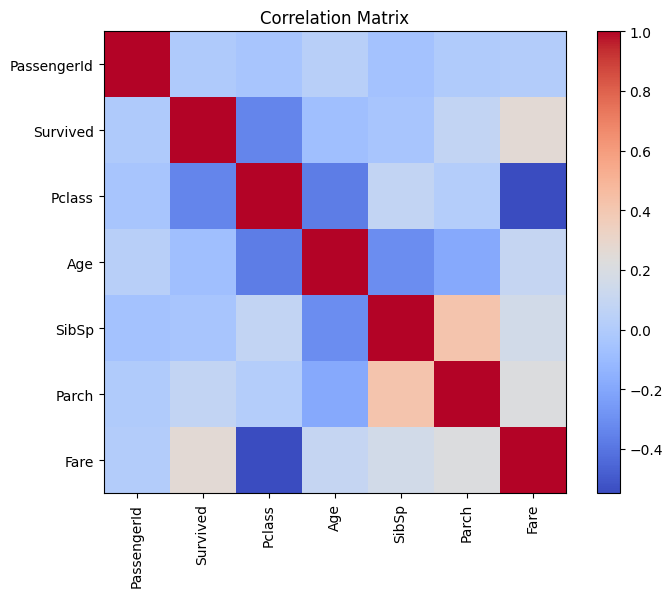

In [6]:
plt.figure(figsize=(8,6))

plt.imshow(corr_matrix, cmap="coolwarm")

plt.colorbar()

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)

plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

plt.title("Correlation Matrix")

plt.show()

Red (or warmer colors) → Positive correlation
Blue (or cooler colors) → Negative correlation
Neutral colors → Weak or no correlation

Note: The exact colors depend on your Matplotlib colormap (coolwarm).

📌 Strong Correlations

In [7]:
corr_matrix["Fare"].sort_values(ascending=False)

Fare           1.000000
Survived       0.257307
Parch          0.216225
SibSp          0.159651
Age            0.096067
PassengerId    0.012658
Pclass        -0.549500
Name: Fare, dtype: float64

Explain which variables have stronger or weaker relationships with Fare.

## ⚠️ What is Multicollinearity?

Multicollinearity occurs when two or more independent features are highly correlated with each other.

Problems caused:

- Reduces model interpretability.
- Can affect Linear Regression coefficients.
- May reduce model stability.

A common practice is to investigate feature pairs with high correlation before training certain models.

📌 Feature Selection using Correlation

In [8]:
corr_matrix["Survived"].abs().sort_values(ascending=False)

Survived       1.000000
Pclass         0.338481
Fare           0.257307
Parch          0.081629
Age            0.077221
SibSp          0.035322
PassengerId    0.005007
Name: Survived, dtype: float64

Features with stronger absolute correlation with the target may be useful candidates for model building.

Remember that correlation is one criterion for feature selection—not the only one.

## 🔍 Observations

- Numerical features show varying levels of correlation.
- Some features have weak relationships with survival.
- Correlation helps identify potentially useful features.
- High correlation between independent variables should be investigated before modeling.

## ✅ Best Practices

- Calculate correlation only for numerical variables.
- Remember that correlation does not imply causation.
- Investigate highly correlated features before training linear models.
- Use correlation as one of several feature selection techniques.

## 🌍 Real-World Scenario

A bank wants to predict loan defaults. Before building the model, analysts calculate correlations among features such as income, loan amount, credit score, and repayment history. Highly correlated features are reviewed to reduce redundancy and improve model interpretability.

## 📝 Summary

In this notebook, we learned what correlation is, how to calculate it using Pandas, interpret correlation coefficients, visualize a correlation matrix, understand multicollinearity, and use correlation as a feature selection aid.